# Resolución — Laboratorio 1 · Financiera Andes
## Modelador de Riesgo de Crédito · Academia Bayes — **Entrega 1** (20% del curso)

**Se publica el miércoles 26 de agosto · fecha límite: domingo 30 de agosto, 23:59 (hora de Chile).**
Entrega: link a este notebook en Colab, **ejecutado de arriba a abajo sin errores**
(`Entorno de ejecución → Reiniciar y ejecutar todo`).

Este es el **laboratorio de la semana 1**: un solo notebook que cubre las clases 1 y 2.
Con la **Financiera Andes** (dataset B) vas a repetir lo que hicimos en clase con Banco
Austral, de punta a punta:

| | Parte | Qué construyes | Puntos |
|---|---|---|---|
| **A** | Clase 1 · Diseño y supuestos | Población, target, exclusiones y las cuatro muestras | 10 |
| **B** | Clase 2 · La fábrica de variables | Matriz y calidad | 8 + 4 bonus |

**Base: 18 puntos**; los ítems 11 y 12 son bonus (+4). `nota = mín(10; 1 + 9 × puntaje / 18)`.

**Puedes empezar hoy mismo por la parte A**, que ya vimos en la clase 1. La **parte B**
necesita la clase del jueves 27 — si la abres antes, vas a encontrarte con conceptos que
todavía no vimos. No hay problema en mirarla, pero no te frustres si no la entiendes aún.

Donde veas `# 👉 TU CÓDIGO`, completa; donde veas **✍️ Tu justificación**, escribe en texto
(se evalúa el argumento, no solo el código).

> Los datos son 100% sintéticos. La Financiera Andes es más riesgosa que el Banco Austral
> de la demo: no esperes los mismos números. Y como cada estudiante trabaja una **muestra
> personal**, tus resultados tampoco son los de tu compañero.

---
## 0. Identificación y muestra personal

Cada estudiante trabaja con una **muestra personal** del dataset (≈60% de los
clientes), determinada por su correo. Así tus números son únicos — la pauta
corrige rangos y método, no valores copiables.

⚠️ Usa el **mismo correo con el que te inscribiste** y no lo cambies durante el curso.

In [1]:
ID_ALUMNO = "ana.riesgo@ejemplo.cl"

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (9, 4.2)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

assert ID_ALUMNO != "tu.correo@ejemplo.cl", "⚠️ Edita ID_ALUMNO con tu correo real"
SEMILLA_PERSONAL = int(hashlib.sha256(f"ANDES-C1-2026-B|{ID_ALUMNO.strip().lower()}".encode()).hexdigest()[:8], 16) % 10**6
print(f"Tu semilla personal: {SEMILLA_PERSONAL}")

Matplotlib is building the font cache; this may take a moment.


Tu semilla personal: 206484


In [2]:
# Versión fija de los datos: evita que una actualización futura cambie los resultados del lab.
BASE = "https://raw.githubusercontent.com/nexolabs-gh/datos-riesgo-credito/feaa1968d0808c44ff228506523b706b677e3020"
PREFIJO = "andes"

clientes       = pd.read_parquet(f"{BASE}/{PREFIJO}_clientes.parquet")
solicitudes    = pd.read_parquet(f"{BASE}/{PREFIJO}_solicitudes.parquet")
comportamiento = pd.read_parquet(f"{BASE}/{PREFIJO}_comportamiento.parquet")
bureau         = pd.read_parquet(f"{BASE}/{PREFIJO}_bureau.parquet")

# ---- Muestra personal (NO modificar esta celda) ----
rng_p = np.random.default_rng(SEMILLA_PERSONAL)
ids = np.sort(clientes["id_cliente"].unique())
mis_clientes = set(rng_p.choice(ids, size=int(len(ids) * 0.60), replace=False))
clientes       = clientes[clientes["id_cliente"].isin(mis_clientes)].reset_index(drop=True)
solicitudes    = solicitudes[solicitudes["id_cliente"].isin(mis_clientes)].reset_index(drop=True)
comportamiento = comportamiento[comportamiento["id_cliente"].isin(mis_clientes)].reset_index(drop=True)
bureau         = bureau[bureau["id_cliente"].isin(mis_clientes)].reset_index(drop=True)
print(f"Tu muestra: {len(clientes):,} clientes · {len(solicitudes):,} solicitudes")

Tu muestra: 27,000 clientes · 34,193 solicitudes


### Primero el diccionario de datos, siempre

Nadie modela columnas que no sabe qué significan. En un banco real el diccionario
de datos se **exige antes** de escribir la primera línea, y si no existe, se
construye entrevistando a quien administra el sistema de origen. Dice qué mide
cada campo, en qué unidad, con qué frecuencia se actualiza y —lo decisivo para
riesgo— **en qué momento del tiempo se llenó**. Adivinar por el nombre de la
columna es la forma más barata de meter una fuga de información en un modelo.

El diccionario de Financiera Andes está publicado junto a los datos:
[`diccionario_andes.md`](https://github.com/nexolabs-gh/datos-riesgo-credito/blob/main/diccionario_andes.md)

La celda siguiente lo muestra **completo — las cuatro tablas que acabamos de
cargar** — y deja definida `mostrar_diccionario(...)` para volver a consultar una
tabla puntual más adelante (por ejemplo `mostrar_diccionario("solicitudes")`).

> ⚠️ Léelo completo antes de decidir qué columnas entran al modelo. Algunas de las columnas problemáticas de este dataset **se delatan en su propia descripción** — la más peligrosa, no: esa hay que razonarla contra el punto de observación.

In [3]:
import urllib.request

from IPython.display import Markdown, display

URL_DICCIONARIO = f"{BASE}/diccionario_{PREFIJO}.md"
_DICCIONARIO = urllib.request.urlopen(URL_DICCIONARIO).read().decode("utf-8")


def mostrar_diccionario(tabla=None):
    """Muestra el diccionario de datos oficial; sin argumento, lo muestra completo."""
    if tabla is None:
        display(Markdown(_DICCIONARIO))
        return
    secciones = _DICCIONARIO.split("\n## ")[1:]
    elegidas = [s for s in secciones if s.lower().startswith(tabla.lower())]
    if not elegidas:
        disponibles = [s.split("(")[0].strip() for s in secciones]
        raise ValueError(f"No existe la tabla {tabla!r}. Disponibles: {disponibles}")
    display(Markdown("## " + elegidas[0]))


mostrar_diccionario()

# Diccionario de datos — Financiera Andes

> Datos **100% sintéticos** generados para el curso *Modelador de Riesgo de Crédito*
> (Academia Bayes). Ninguna persona ni institución real está representada.

Panel mensual: 2023-07 a 2026-06. Montos en CLP.

## clientes (andes_clientes)
| Columna | Descripción |
|---|---|
| id_cliente | Identificador único del cliente |
| fecha_alta_cliente | Mes de alta en la institución (YYYY-MM) |
| edad | Edad en años al inicio del panel |
| sexo | M / F |
| region | Región de residencia (Chile) |
| estado_civil | soltero / casado / divorciado / viudo |
| nivel_educacional | básica / media / técnica / universitaria / postgrado |
| tipo_empleo | dependiente / independiente / jubilado |
| renta_liquida | Renta líquida mensual declarada (CLP). Puede venir vacía |
| n_dependientes | Número de cargas familiares |

## solicitudes (andes_solicitudes)
| Columna | Descripción |
|---|---|
| id_solicitud | Identificador de la solicitud |
| id_cliente | Cliente que solicita |
| fecha_solicitud | Mes de la solicitud (YYYY-MM) |
| monto_solicitado | Monto del crédito de consumo (CLP) |
| plazo_meses | Plazo en meses |
| destino | Uso declarado del crédito |
| canal | sucursal / web / app |
| aprobada | La solicitud fue aprobada y cursada |
| estado_actual | Estado del crédito **a la fecha de corte 2026-06** |
| marca_fraude | Fraude confirmado posteriormente |

## comportamiento_mensual (andes_comportamiento)
| Columna | Descripción |
|---|---|
| id_cliente, mes | Llave panel (YYYY-MM) |
| saldo_linea / cupo_linea | Saldo y cupo de línea de crédito (CLP) |
| saldo_tc / cupo_tc | Saldo y cupo de tarjeta de crédito (CLP) |
| saldo_consumo | Saldo vigente de créditos de consumo en cuotas |
| dias_mora | Días de mora del cliente al cierre del mes |
| monto_facturado / monto_pagado | Facturación y pago del mes |
| abonos_cuenta | Abonos totales a cuentas del cliente en el mes |
| saldo_ahorro | Saldo de ahorro/vista al cierre |
| n_productos | Número de productos vigentes |

## bureau_mensual (andes_bureau)
| Columna | Descripción |
|---|---|
| id_cliente, mes | Llave panel (YYYY-MM) |
| deuda_otras_inst | Deuda en otras instituciones (CLP) |
| n_otras_inst | Número de otras instituciones con deuda |
| consultas_mes | Consultas al bureau en el mes |
| peor_mora_sistema | Peor mora del cliente en el sistema (0/30/60/90) |


---
# Parte A · Diseño y supuestos
### Clase 1 · 10 puntos

Cierras esta parte con la **población de modelación** de la Financiera Andes: quién entra,
qué es un default, quién queda fuera y cómo se reparten las muestras. Es el contrato del
proyecto — todo lo que viene después se apoya acá.

---
## 1. Reconocimiento del terreno (1 punto)

Antes de modelar, entiende qué te entregaron. Responde **con código y con texto**.

In [4]:
for nombre, df in [("clientes", clientes), ("solicitudes", solicitudes),
                   ("comportamiento", comportamiento), ("bureau", bureau)]:
    print(f"{nombre:15s} {df.shape[0]:>9,} × {df.shape[1]}")
print("Solicitudes:", solicitudes["fecha_solicitud"].min(), "→", solicitudes["fecha_solicitud"].max())
print(f"Aprobación: {solicitudes['aprobada'].mean():.1%}")
print(f"Missing renta: {clientes['renta_liquida'].isna().mean():.1%}")

clientes           27,000 × 10
solicitudes        34,193 × 10
comportamiento    624,555 × 13
bureau            624,555 × 6
Solicitudes: 2024-01 → 2026-06
Aprobación: 64.0%
Missing renta: 20.1%


**✍️ Tu justificación (1a):** ¿cuál es la unidad de análisis del modelo que
construiremos y qué población representa? ¿Modelaremos toda la demanda o solo
una parte? ¿Qué implicancia tiene eso?

**Respuesta de referencia:** la unidad de análisis es cada solicitud de consumo cursada, es decir, aprobada. No modelamos toda la demanda: aprendemos solo de quienes superaron el filtro de aprobación, porque los rechazados no tienen un desempeño posterior observable. Esto introduce sesgo de selección y limita la aplicación directa del modelo a rechazados; en un proyecto real lo documentaría y evaluaría técnicas de *reject inference*.

---
## 2. Sustenta la definición de default (2 puntos)

Construye la **matriz de roll rates** mensual de la Financiera Andes (bandas:
al día / 1–29 / 30–59 / 60–89 / 90+) y a partir de ella **defiende o cuestiona**
usar 90+ como definición de default en esta cartera.

In [5]:
def banda_mora(dias):
    return np.select([dias == 0, dias <= 29, dias <= 59, dias <= 89],
                     ["0. al día", "1. 1-29", "2. 30-59", "3. 60-89"], default="4. 90+")

panel = comportamiento[["id_cliente", "mes", "dias_mora"]].copy()
panel["banda"] = banda_mora(panel["dias_mora"])
panel = panel.sort_values(["id_cliente", "mes"])
panel["banda_sig"] = panel.groupby("id_cliente")["banda"].shift(-1)
pares = panel.dropna(subset=["banda_sig"])
roll = (pd.crosstab(pares["banda"], pares["banda_sig"], normalize="index") * 100).round(1)
roll

banda_sig,0. al día,1. 1-29,2. 30-59,3. 60-89,4. 90+
banda,,,,,
0. al día,95.5,4.5,0.0,0.0,0.0
1. 1-29,31.1,28.6,40.3,0.0,0.0
2. 30-59,10.7,0.0,44.4,44.9,0.0
3. 60-89,3.8,0.0,0.0,33.5,62.8
4. 90+,2.1,0.0,0.0,0.0,97.9


**✍️ Tu justificación (2a):** ¿dónde está el "punto de no retorno" en esta
cartera? Compara la probabilidad de cura entre bandas y concluye si 90+ es una
definición razonable de default para la Financiera Andes.

**Respuesta de referencia:** el quiebre aparece antes de entrar a 90+. Desde 1–29 días, 31,1% vuelve a estar al día; desde 30–59 la cura baja a 10,7%; y desde 60–89 solo 3,8% vuelve al día mientras 62,8% pasa a 90+. Una vez en 90+, 97,9% permanece allí y apenas 2,1% cura. Por eso 90+ es una definición razonable de default para esta cartera: a partir de ese punto la recuperación es residual.

---
## 3. Construye el target (3 puntos — el corazón de esta entrega)

Recuerda la **máquina del tiempo** de la clase: para etiquetar no necesitas
adivinar el futuro — te paras en el pasado (la fecha de cada solicitud) y su
"futuro" de 12 meses **ya ocurrió y está en el panel**. Y cada solicitud lleva
**su propia ventana**: la de enero se observa hasta el enero siguiente; la de
junio, hasta el junio siguiente.

Implementa `construir_target` con la definición del curso:
**malo = alcanzar 90+ DPD dentro de los 12 meses posteriores al punto de
observación** (mes de la solicitud). Marca además los **indeterminados**
(peor mora 30–89) y deja con target nulo a quien no tenga ventana completa.

Regla de oro: la ventana va de $t_0+1$ a $t_0+12$. **Ni un mes más, ni el mes
de la solicitud.**

In [6]:
# Preparación (se entrega hecha): mora en formato ancho cliente × mes
mora_w = comportamiento.pivot_table(index="id_cliente", columns="mes",
                                    values="dias_mora", aggfunc="first")
meses = list(mora_w.columns)
pos_mes = {m: k for k, m in enumerate(meses)}
M = mora_w.to_numpy()
fila_de = {c: k for k, c in enumerate(mora_w.index)}

cursadas = solicitudes[solicitudes["aprobada"]].copy()
cursadas["_t"] = cursadas["fecha_solicitud"].map(pos_mes)
cursadas["_i"] = cursadas["id_cliente"].map(fila_de)

In [7]:
def construir_target(cursadas, M, n_meses_panel, ventana=12, umbral_malo=90, umbral_gris=30):
    out = cursadas.copy()
    peor = np.full(len(out), np.nan)
    for k, (i, t0) in enumerate(zip(out["_i"], out["_t"])):
        fin = t0 + ventana
        if fin <= n_meses_panel - 1:
            peor[k] = M[i, t0 + 1: fin + 1].max()
    out["peor_dpd_12m"] = peor
    out["malo"] = np.where(np.isnan(peor), np.nan, (peor >= umbral_malo).astype(float))
    out["indeterminado"] = (peor >= umbral_gris) & (peor < umbral_malo)
    return out

etiquetadas = construir_target(cursadas, M, len(meses))
etiquetadas[["fecha_solicitud", "peor_dpd_12m", "malo", "indeterminado"]].head()

,fecha_solicitud,peor_dpd_12m,malo,indeterminado
1,2024-01,0.0,0.0,False
2,2024-01,0.0,0.0,False
4,2024-01,0.0,0.0,False
6,2024-01,0.0,0.0,False
7,2024-01,0.0,0.0,False


In [8]:
# ---- Verificación automática (NO modificar): sanidad del target ----
_completa = etiquetadas[etiquetadas["malo"].notna()]
assert etiquetadas.loc[etiquetadas["fecha_solicitud"] > "2025-06", "malo"].isna().all(), \
    "❌ Cosechas posteriores a 2025-06 no tienen ventana completa: su target debe ser NaN"
assert 0.05 <= _completa["malo"].mean() <= 0.20, \
    f"❌ Tasa de malos fuera de rango razonable: {_completa['malo'].mean():.1%} — revisa la ventana"
assert (_completa.loc[_completa["indeterminado"], "malo"] == 0).all(), \
    "❌ Un indeterminado no puede ser malo a la vez"
print(f"✅ Target OK · tasa de malos (ventana completa): {_completa['malo'].mean():.1%}")

✅ Target OK · tasa de malos (ventana completa): 10.1%


---
## 4. Población de modelación: cliente único, exclusiones y columnas prohibidas (2 puntos)

**(4a) Cliente único.** Un cliente activo puede tener varias solicitudes en el
período de modelación (2024-09 → 2025-06). **Regla del curso**: cada cliente
entra **una sola vez**, con su **primera** solicitud del período; si esa fila
después cae excluida, el cliente sale (no se reemplaza por otra solicitud suya).
Cuenta cuántas filas repetidas descartas.

**(4b) Exclusiones.** Sobre esa población, aplica y reporta la cascada de
exclusiones: ventana completa, sin fraude, sin indeterminados, y clientes con
≥ 6 meses de historia previa. Justifica cada una.

**(4c) Columnas prohibidas.** En estas tablas hay **al menos dos columnas** que
un modelo de admisión jamás podría usar como predictor porque contienen
información posterior al punto de observación. **Identifícalas, demuestra el
problema con datos** (por ejemplo, mide su poder predictivo) y explica el
mecanismo de la fuga. Pista de la sutil: mira cómo evoluciona el **cupo** de los
clientes que se deterioran.

In [9]:
periodo = etiquetadas[etiquetadas["fecha_solicitud"].between("2024-09", "2025-06")].copy()
antes, repetidos = len(periodo), etiquetadas["fecha_solicitud"].between("2024-09", "2025-06").sum() - \
    etiquetadas.loc[etiquetadas["fecha_solicitud"].between("2024-09", "2025-06"), "id_cliente"].nunique()
periodo = periodo.sort_values("fecha_solicitud", kind="stable").drop_duplicates("id_cliente", keep="first")
print(f"solicitudes del período: {antes:,} → clientes únicos: {len(periodo):,} "
      f"(descartadas {repetidos:,}, {repetidos / antes:.0%})")
assert periodo["id_cliente"].is_unique

solicitudes del período: 6,916 → clientes únicos: 6,099 (descartadas 817, 12%)


**✍️ Tu justificación (4a):** ¿por qué no dejamos que un cliente aparezca dos
veces? Menciona qué pasaría con un split aleatorio DEV/HO por fila, y qué
alternativas existen cuando la cartera es demasiado chica para este lujo.

**Respuesta de referencia:** las filas de un mismo cliente no son independientes. Si se separan solicitudes al azar, el mismo cliente puede quedar en DEV y HO y el hold-out deja de representar datos realmente no vistos; las métricas quedarían infladas por fuga de identidad. Con una cartera pequeña se puede conservar más de una observación, pero el split debe hacerse por cliente, documentando el supuesto, y conviene usar bootstrap para medir la incertidumbre.

In [10]:
alta_idx = clientes.set_index("id_cliente")["fecha_alta_cliente"].map(
    lambda s: (pd.Period(s, freq="M") - pd.Period(meses[0], freq="M")).n)
periodo["antig_meses"] = periodo["_t"] - periodo["id_cliente"].map(alta_idx)

n0 = periodo["malo"].notna().sum()
paso1 = periodo[periodo["malo"].notna() & ~periodo["marca_fraude"]]
paso2 = paso1[~paso1["indeterminado"]]
entrenables = paso2[paso2["antig_meses"] >= 6].copy()
print(f"con ventana completa: {n0:,}  → sin fraude: {len(paso1):,}"
      f"  → sin indeterminados: {len(paso2):,}  → con historia ≥6m: {len(entrenables):,}")

con ventana completa: 6,099  → sin fraude: 6,088  → sin indeterminados: 5,505  → con historia ≥6m: 4,621


AUC de estado_actual: 0.986 → columna ex-post


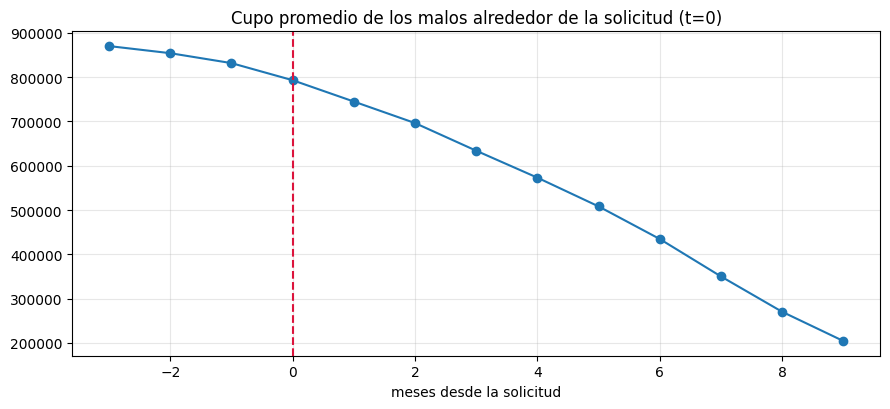

In [11]:
from sklearn.metrics import roc_auc_score
fuga = entrenables["estado_actual"].isin(["castigado", "renegociado"]).astype(int)
print(f"AUC de estado_actual: {roc_auc_score(entrenables['malo'], fuga):.3f} → columna ex-post")

# Fuga sutil: el cupo se recorta DESPUÉS del deterioro (política reactiva).
# Usar cupo de meses posteriores a t0 filtraría el futuro hacia la variable.
cupo_w = comportamiento.pivot_table(index="id_cliente", columns="mes",
                                    values="cupo_linea", aggfunc="first").to_numpy()
malos = entrenables[entrenables["malo"] == 1].head(300)
prom = {d: np.nanmean([cupo_w[fila_de[c], t + d]
        for c, t in zip(malos["id_cliente"], malos["_t"])
        if 0 <= t + d < len(meses)]) for d in range(-3, 10)}
pd.Series(prom).plot(marker="o", title="Cupo promedio de los malos alrededor de la solicitud (t=0)")
plt.axvline(0, color="crimson", ls="--"); plt.xlabel("meses desde la solicitud")
plt.tight_layout(); plt.show()

**✍️ Tu justificación (4b):** explica por qué aplicaste cada exclusión.

**✍️ Tu justificación (4c):** nombra las columnas prohibidas, el mecanismo de cada fuga y cómo la detectarías en un proyecto real.

**Respuesta de referencia (4b):** exijo la ventana completa para no etiquetar como buenos a créditos cuyo default todavía no alcanzamos a observar; excluyo fraude porque responde a otro mecanismo, no al riesgo de crédito; retiro la zona 30–89 para entrenar con casos inequívocos; y exijo al menos seis meses de historia para construir variables retrospectivas comparables.

**Respuesta de referencia (4c):** `estado_actual` es una foto del desenlace a 2026-06 y alcanza AUC 0,986, por lo que contiene información ex-post. `marca_fraude` también se completa después y solo debe usarse para excluir. La fuga más sutil aparece si se usa `cupo_linea` de meses posteriores a $t_0$: el gráfico muestra que el cupo cae después de la solicitud por una decisión reactiva del banco. El cupo en $t_0-1$ sí es válido. En un proyecto real lo detectaría con el diccionario de datos, el linaje temporal, AUC/IV univariados sospechosos y una gráfica de la variable alrededor del punto de observación.

---
## 5. Cosechas y esquema muestral (2 puntos)

**(5a)** Tabla y gráfico de **tasa de malos por cosecha** (2024-09 → 2025-06).
¿Qué observas hacia las cosechas finales? ¿Qué implicancia tiene para el modelo?

**(5b)** Construye las muestras del curso y reporta n, malos y tasa por muestra:
- **DEV/HO**: cosechas 2024-09 → 2025-01, split aleatorio 75/25 (usa `SEMILLA_PERSONAL`)
- **OOT**: cosechas 2025-02 → 2025-06
- **TTD**: solicitudes cursadas desde 2025-07 con **≥ 6 meses de historia** (sin target).
  El mínimo de historia es el mismo de la población entrenable: sin él no hay ventanas
  hacia atrás que calcular en la parte B.

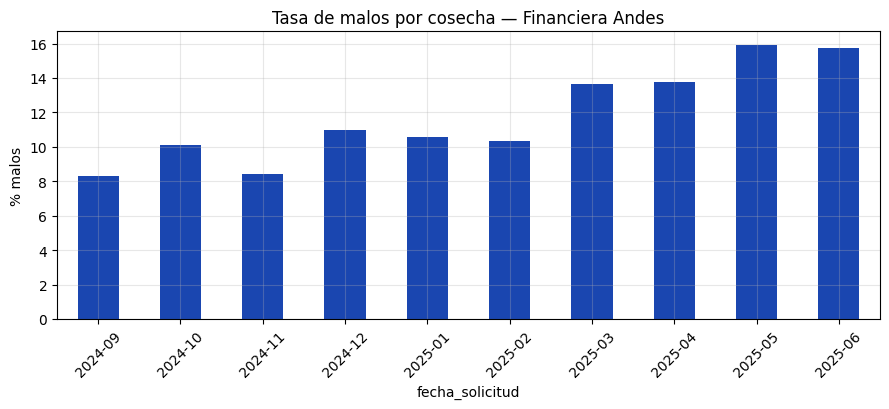

,mean,count
fecha_solicitud,,
2024-09,8.3%,482
2024-10,10.1%,475
2024-11,8.4%,535
2024-12,11.0%,509
2025-01,10.6%,540
2025-02,10.3%,455
2025-03,13.7%,417
2025-04,13.8%,400
2025-05,15.9%,421


In [12]:
tc = entrenables.groupby("fecha_solicitud")["malo"].agg(["mean", "count"])
(tc["mean"] * 100).plot(kind="bar", color="#1A46B0",
                        title="Tasa de malos por cosecha — Financiera Andes")
plt.ylabel("% malos"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
tc.style.format({"mean": "{:.1%}"})

In [13]:
rng = np.random.default_rng(SEMILLA_PERSONAL)
entrenables["muestra"] = np.where(
    entrenables["fecha_solicitud"] <= "2025-01",
    np.where(rng.random(len(entrenables)) < 0.75, "DEV", "HO"), "OOT")
ttd = etiquetadas[(etiquetadas["fecha_solicitud"] >= "2025-07")].copy()
ttd["antig_meses"] = ttd["_t"] - ttd["id_cliente"].map(alta_idx)
ttd = ttd[ttd["antig_meses"] >= 6]

tabla = entrenables.groupby("muestra").agg(creditos=("malo", "size"),
                                           malos=("malo", "sum"), tasa=("malo", "mean"))
tabla.loc["TTD"] = [len(ttd), np.nan, np.nan]
tabla.style.format({"tasa": "{:.1%}", "malos": "{:.0f}", "creditos": "{:,.0f}"})

,creditos,malos,tasa
muestra,,,
DEV,"1,910",186,9.7%
HO,631,60,9.5%
OOT,"2,080",287,13.8%
TTD,"8,628",nan,nan%


In [14]:
# ---- Verificación automática (NO modificar): esquema muestral ----
assert entrenables["id_cliente"].is_unique, \
    "❌ Hay clientes repetidos en la población de modelación: aplica la regla de cliente único (4a)"
assert set(entrenables["muestra"].unique()) == {"DEV", "HO", "OOT"}
assert entrenables.loc[entrenables["muestra"] == "OOT", "fecha_solicitud"].min() >= "2025-02", \
    "❌ OOT contaminada con cosechas de desarrollo"
assert entrenables.loc[entrenables["muestra"].isin(["DEV", "HO"]), "fecha_solicitud"].max() <= "2025-01", \
    "❌ DEV/HO contiene cosechas del período OOT"
_p = entrenables["muestra"].value_counts(normalize=True)
assert 0.65 <= _p.get("DEV", 0) / (_p.get("DEV", 0) + _p.get("HO", 0)) <= 0.85, "❌ split 75/25 fuera de rango"
_alta_ttd = clientes.set_index("id_cliente")["fecha_alta_cliente"].map(
    lambda s: (pd.Period(s, freq="M") - pd.Period(meses[0], freq="M")).n)
_hist_ttd = ttd["_t"] - ttd["id_cliente"].map(_alta_ttd)
assert (ttd["fecha_solicitud"] >= "2025-07").all(), "❌ TTD contiene solicitudes anteriores a 2025-07"
assert (_hist_ttd >= 6).all(), "❌ TTD contiene clientes con menos de 6 meses de historia"
assert ttd["malo"].isna().all(), "❌ TTD no debe tener target observado"
print("✅ Esquema muestral OK")

✅ Esquema muestral OK


**✍️ Tu lectura (5a):** describe el cambio de la tasa por cosecha y su
implicancia para el modelo.

**✍️ Tu justificación (5c):** explica con tus palabras el rol de cada muestra
(DEV, HO, OOT, TTD) y por qué la OOT "no se toca" hasta la validación.

**Respuesta de referencia (5a):** la tasa sube desde 8,3% en 2024-09 hasta 15,9% en 2025-05 y cierra en 15,8% en 2025-06. Además, OOT queda en 13,8%, por encima de DEV (9,7%). Hay deterioro temporal, por lo que no basta una validación aleatoria: hay que medir estabilidad y probablemente revisar la calibración antes de producción.

**Respuesta de referencia (5c):** DEV se usa para estimar y seleccionar; HO mide sobreajuste en el mismo período; OOT prueba generalización en cosechas posteriores; y TTD representa la población actual sin target para monitorear cambio poblacional, por ejemplo con PSI. La OOT no se toca durante el desarrollo porque cada decisión tomada mirándola la convierte en otra muestra de ajuste y deja de ser una prueba temporal honesta.

---
# Puente · de la parte A a la parte B

La celda que sigue deja a **todo el curso en el mismo punto de partida** para la fábrica de
variables: reconstruye la población sobre tu muestra personal y la deja en el formato que
usa la parte B. **No la modifiques.**

Hace tres cosas, y conviene entender por qué:

1. **Reconstruye el terreno de la parte A** — target, cliente único, exclusiones y muestras.
   Es la solución de referencia: si tu parte A quedó a medias, **la parte B corre igual** y no
   pierdes la entrega. Tu parte A se corrige por tu propio código y tus justificaciones.
2. **Compara su resultado con el tuyo** y te dice si coinciden. Es tu primera corrección
   automática: si difieren mucho, vuelve a la sección 4 antes de seguir.
3. **Amplía la población**: la parte A se quedó con los créditos *entrenables* (sin
   indeterminados). La fábrica, en cambio, calcula variables para **todos** — indeterminados
   y TTD incluidos — porque en producción hay que puntuar a todo el que llega. Los
   indeterminados se excluyen recién en el **screening** (sección 11), que es donde se
   necesita un target definido.

In [15]:
mora_w = comportamiento.pivot_table(index="id_cliente", columns="mes",
                                    values="dias_mora", aggfunc="first")
meses = list(mora_w.columns)
pos_mes = {m: k for k, m in enumerate(meses)}
M = mora_w.to_numpy()
fila_de = {c: k for k, c in enumerate(mora_w.index)}

cursadas = solicitudes[solicitudes["aprobada"]].copy()
cursadas["_t"] = cursadas["fecha_solicitud"].map(pos_mes)
cursadas["_i"] = cursadas["id_cliente"].map(fila_de)

def construir_target(cursadas, M, n_meses, ventana=12, umbral_malo=90, umbral_gris=30):
    out = cursadas.copy()
    peor = np.full(len(out), np.nan)
    for k, (i, t0) in enumerate(zip(out["_i"], out["_t"])):
        fin = t0 + ventana
        if fin <= n_meses - 1:
            peor[k] = M[i, t0 + 1: fin + 1].max()
    out["peor_dpd_12m"] = peor
    out["malo"] = np.where(np.isnan(peor), np.nan, (peor >= umbral_malo).astype(float))
    out["indeterminado"] = (peor >= umbral_gris) & (peor < umbral_malo)
    return out

etiquetadas = construir_target(cursadas, M, len(meses))

antig = clientes.set_index("id_cliente")["fecha_alta_cliente"].map(
    lambda s: (pd.Period(s, freq="M") - pd.Period(meses[0], freq="M")).n)

periodo = etiquetadas[etiquetadas["fecha_solicitud"].between("2024-09", "2025-06")]
periodo = periodo.sort_values("fecha_solicitud", kind="stable").drop_duplicates(
    "id_cliente", keep="first").copy()
periodo["antiguedad_meses"] = periodo["_t"] - periodo["id_cliente"].map(antig)

base = periodo[periodo["malo"].notna() & ~periodo["marca_fraude"]
               & (periodo["antiguedad_meses"] >= 6)].copy()
rng = np.random.default_rng(SEMILLA_PERSONAL)
base["muestra"] = np.where(base["fecha_solicitud"] <= "2025-01",
                           np.where(rng.random(len(base)) < 0.75, "DEV", "HO"), "OOT")

ttd = etiquetadas[etiquetadas["fecha_solicitud"] >= "2025-07"].copy()
ttd["antiguedad_meses"] = ttd["_t"] - ttd["id_cliente"].map(antig)
ttd = ttd[ttd["antiguedad_meses"] >= 6]
ttd["muestra"] = "TTD"

poblacion = pd.concat([base, ttd], ignore_index=True)
print(poblacion["muestra"].value_counts().reindex(["DEV", "HO", "OOT", "TTD"]).to_string())
print(f"\nTasa de malos (sin indeterminados): "
      f"{base.loc[~base['indeterminado'], 'malo'].mean():.1%}")

# ---- ¿Coincide con TU parte A? (esta es tu primera corrección automática) ----
try:
    _tuyo, _ref = len(entrenables), len(base[~base["indeterminado"]])
    _d = abs(_tuyo - _ref) / _ref
    _v = "✅ coinciden" if _d < 0.02 else f"⚠️ difieren {_d:.0%} — revisa tu sección 4 antes de seguir"
    print(f"\nTu parte A: {_tuyo:,} entrenables · referencia: {_ref:,}  → {_v}")
except (NameError, TypeError):
    print("\n⚠️ No encontré `entrenables` de la parte A. La parte B corre igual; "
          "revisa tu sección 4 cuando puedas.")

muestra
DEV    2086
HO      684
OOT    2315
TTD    8628

Tasa de malos (sin indeterminados): 11.5%

Tu parte A: 4,621 entrenables · referencia: 4,621  → ✅ coinciden


---
# Parte B · La fábrica de variables
### Clase 2 · 8 puntos + 4 bonus

Ahora conviertes esas cuatro tablas crudas en una **matriz de modelación**: una fila por
solicitud, decenas de columnas candidatas, todas ancladas al punto de observación. Y haces
el primer filtro con WoE e IV.

> ⚠️ Esta parte necesita la **clase del jueves 27**.

---
## 6. El panel en formato ancho (1 punto)

Para calcular ventanas hacia atrás necesitas, por cada serie del panel, una
**matriz cliente × mes** alineada con `mora_w`.

**(6a)** Completa `pivotar()` y construye el diccionario `PANEL` con las series
del comportamiento y del bureau.

**(6b)** Agrega las **series derivadas**: utilización de línea y de tarjeta
(calculadas **mes a mes**, no como cociente de promedios), deuda interna y deuda
total.

In [16]:
def pivotar(df, columna):
    ancho = df.pivot_table(index="id_cliente", columns="mes", values=columna, aggfunc="first")
    return ancho.reindex(index=mora_w.index, columns=meses).to_numpy()

SERIES_COMPORTAMIENTO = ["dias_mora", "saldo_linea", "cupo_linea", "saldo_tc", "cupo_tc",
                         "saldo_consumo", "monto_pagado", "monto_facturado",
                         "abonos_cuenta", "saldo_ahorro", "n_productos"]
SERIES_BUREAU = ["deuda_otras_inst", "n_otras_inst", "consultas_mes", "peor_mora_sistema"]

PANEL = {c: pivotar(comportamiento, c) for c in SERIES_COMPORTAMIENTO}
PANEL.update({c: pivotar(bureau, c) for c in SERIES_BUREAU})
print(f"{len(PANEL)} series, cada una de {PANEL['dias_mora'].shape}")

15 series, cada una de (27000, 36)


In [17]:
with np.errstate(divide="ignore", invalid="ignore"):
    PANEL["uso_linea"] = np.where(PANEL["cupo_linea"] > 0,
                                  PANEL["saldo_linea"] / PANEL["cupo_linea"], np.nan)
    PANEL["uso_tc"] = np.where(PANEL["cupo_tc"] > 0,
                               PANEL["saldo_tc"] / PANEL["cupo_tc"], np.nan)
PANEL["deuda_interna"] = PANEL["saldo_linea"] + PANEL["saldo_tc"] + PANEL["saldo_consumo"]
PANEL["deuda_total"] = PANEL["deuda_interna"] + PANEL["deuda_otras_inst"]
PANEL["en_mora"] = np.where(np.isnan(PANEL["dias_mora"]), np.nan,
                            (PANEL["dias_mora"] > 0).astype(float))
PANEL["en_mora_sistema"] = np.where(np.isnan(PANEL["peor_mora_sistema"]), np.nan,
                                    (PANEL["peor_mora_sistema"] > 0).astype(float))
print(f"{len(PANEL)} series disponibles para la fábrica")

21 series disponibles para la fábrica


**✍️ Tu justificación (6c):** ¿por qué la utilización se calcula **mes a mes**
y no como `promedio(saldo) / promedio(cupo)`? Da un ejemplo numérico donde ambas
formas den resultados distintos.

**Respuesta de referencia:** supongamos que el primer mes el saldo/cupo es 100/1.000 (10%) y el segundo 900/3.000 (30%). El promedio mensual de uso es 20%, mientras que dividir los promedios da 500/2.000 = 25%. El primer cálculo conserva la presión de deuda que el cliente enfrentó cada mes; el segundo pondera implícitamente más los meses con cupos grandes y puede diluir o exagerar esa señal.

---
## 7. El motor de ventanas (2 puntos — el corazón del lab)

Implementa `agregar_ventana`. Para una solicitud con punto de observación $t_0$
y ventana de $k$ meses, la ventana es:

$$[\,t_0-k,\; t_0-1\,]$$

⚠️ **La trampa está en el índice.** En numpy, `matriz[i, a:b]` **no incluye** la
columna `b`. Si escribes `t0+1` como límite superior, estás metiendo el mes de la
solicitud dentro de la ventana — y contaminas **todas** tus variables.

Implementa también los cinco agregadores. Ojo con dos:
- `delta`: variación relativa entre los **extremos** de la ventana, `(fin/inicio) − 1`.
  Protege la división con `np.maximum(inicio, 1)`.
- `recencia`: meses desde el último mes con evento. Si **no hubo** evento en la
  ventana, devuelve `k+1` (valor censurado) — nunca el mismo valor que
  "el evento fue al principio de la ventana".

In [18]:
def agregar_ventana(matriz, filas, t0s, k, funcion):
    """Agrega `matriz` sobre la ventana [t0-k, t0-1] de cada solicitud."""
    salida = np.full(len(filas), np.nan)
    for t0 in np.unique(t0s):
        sel = t0s == t0
        inicio = max(t0 - k, 0)
        salida[sel] = funcion(matriz[filas[sel], inicio:t0])   # t0 NO se incluye
    return salida


def prom(V):  return np.nanmean(V, axis=1)
def vmax(V):  return np.nanmax(V, axis=1)
def suma(V):  return np.nansum(V, axis=1)

def delta(V):
    return V[:, -1] / np.maximum(V[:, 0], 1) - 1

def recencia(V):
    evento = np.nan_to_num(V, nan=0.0) > 0
    k = evento.shape[1]
    ultimo = k - 1 - np.argmax(evento[:, ::-1], axis=1)
    return np.where(evento.any(axis=1), k - ultimo, k + 1)

AGREGADORES = {"prom": prom, "max": vmax, "suma": suma, "delta": delta, "recencia": recencia}

In [19]:
# ---- Verificación automática (NO modificar): el ancla temporal ----
filas_p = poblacion["_i"].to_numpy()
t0s_p   = poblacion["_t"].to_numpy()

# Matriz de prueba donde el valor de cada celda ES el índice del mes.
# Así, sobre la ventana [t0-k, t0-1]:  máximo = t0-1  y  mínimo = t0-k.
_M_test = np.tile(np.arange(len(meses), dtype=float), (PANEL["dias_mora"].shape[0], 1))

_maximos = agregar_ventana(_M_test, filas_p, t0s_p, 3, vmax)
assert np.allclose(_maximos, t0s_p - 1), (
    "❌ FUGA: el último mes de tu ventana es "
    f"t0+{int(np.median(_maximos - t0s_p))}, y debe ser t0-1. "
    "Revisa el límite superior del slice: matriz[filas, inicio:t0] NO incluye t0")

_minimos = agregar_ventana(_M_test, filas_p, t0s_p, 3, lambda V: np.nanmin(V, axis=1))
assert np.allclose(_minimos, np.maximum(t0s_p - 3, 0)), \
    "❌ El primer mes de la ventana de 3 meses debe ser t0-3"

_r = recencia(np.array([[0., 0., 0.], [1., 0., 0.], [0., 0., 1.]]))
assert list(_r) == [4, 3, 1], f"❌ recencia mal implementada: {list(_r)} (esperado [4, 3, 1])"
print("✅ Ancla temporal correcta: ventana = [t0-k, t0-1] · recencia bien censurada")

✅ Ancla temporal correcta: ventana = [t0-k, t0-1] · recencia bien censurada


---
## 8. Declara tu fábrica (2 puntos)

Escribe la lista `FABRICA` con tuplas `(serie, agregador, ventanas, plantilla)`.

**Requisitos mínimos de la entrega:**
- Al menos **40 variables de ventana**.
- Al menos **4 familias** distintas (mora propia, utilización, deuda, pagos,
  ahorro/ingreso, bureau, consultas).
- Las tres ventanas **3, 6 y 12 meses** presentes.
- Al menos **3 agregadores** distintos.
- Convención de nombres `<concepto>_<agregador>_<ventana>` respetada.

Añade después las **fotos** al último cierre disponible ($t_0-1$).

In [20]:
FABRICA = [
    # mora propia
    ("dias_mora",         "max",      (3, 6, 12), "dias_mora_max_{k}m"),
    ("dias_mora",         "prom",     (3, 6, 12), "dias_mora_prom_{k}m"),
    ("en_mora",           "suma",     (3, 6, 12), "n_meses_mora_{k}m"),
    ("en_mora",           "recencia", (12,),      "meses_desde_mora_12m"),
    # utilización
    ("uso_linea",         "prom",     (3, 6, 12), "uso_linea_prom_{k}m"),
    ("uso_linea",         "max",      (3, 6, 12), "uso_linea_max_{k}m"),
    ("uso_tc",            "prom",     (3, 6, 12), "uso_tc_prom_{k}m"),
    ("uso_tc",            "max",      (3, 6, 12), "uso_tc_max_{k}m"),
    # deuda y saldos
    ("saldo_consumo",     "prom",     (3, 6, 12), "saldo_consumo_prom_{k}m"),
    ("deuda_interna",     "prom",     (3, 6, 12), "deuda_interna_prom_{k}m"),
    ("deuda_total",       "prom",     (3, 6, 12), "deuda_total_prom_{k}m"),
    ("deuda_total",       "delta",    (6, 12),    "deuda_total_delta_{k}m"),
    # pagos
    ("monto_pagado",      "suma",     (3, 6, 12), "pagos_{k}m"),
    ("monto_facturado",   "suma",     (3, 6, 12), "facturacion_{k}m"),
    # ahorro e ingreso observado
    ("abonos_cuenta",     "prom",     (3, 6, 12), "abonos_prom_{k}m"),
    ("saldo_ahorro",      "prom",     (3, 6, 12), "saldo_ahorro_prom_{k}m"),
    # bureau externo
    ("deuda_otras_inst",  "prom",     (3, 6, 12), "deuda_otras_prom_{k}m"),
    ("deuda_otras_inst",  "delta",    (6,),       "delta_deuda_otras_{k}m"),
    ("n_otras_inst",      "prom",     (3, 6, 12), "n_otras_inst_prom_{k}m"),
    ("peor_mora_sistema", "max",      (3, 6, 12), "peor_mora_sistema_{k}m"),
    # consultas
    ("consultas_mes",     "suma",     (3, 6, 12), "consultas_{k}m"),
    ("consultas_mes",     "recencia", (12,),      "meses_desde_consulta_12m"),
]

META = ["id_solicitud", "id_cliente", "fecha_solicitud", "_t", "_i",
        "muestra", "malo", "indeterminado", "peor_dpd_12m"]
X = poblacion[META + ["antiguedad_meses", "monto_solicitado", "plazo_meses",
                      "destino", "canal"]].copy()

for serie, agg, ventanas, plantilla in FABRICA:
    for k in ventanas:
        X[plantilla.format(k=k)] = agregar_ventana(
            PANEL[serie], filas_p, t0s_p, k, AGREGADORES[agg])
print(f"Variables de ventana: {len(X.columns) - len(META) - 5}")

Variables de ventana: 59


In [21]:
t_ult = np.maximum(t0s_p - 1, 0)
FOTOS = ["dias_mora", "saldo_linea", "cupo_linea", "saldo_tc", "cupo_tc",
         "saldo_consumo", "saldo_ahorro", "deuda_otras_inst", "n_productos",
         "peor_mora_sistema", "uso_linea", "uso_tc"]
for serie in FOTOS:
    X[f"{serie}_ult"] = PANEL[serie][filas_p, t_ult]
print(f"Fotos añadidas: {len(FOTOS)}")

Fotos añadidas: 12


---
## 9. Ratios de negocio (1,5 puntos)

Construye **al menos 4 ratios** de negocio. Sugerencias (puedes proponer otros):
utilización ya la tienes; faltan carga financiera, pago sobre facturación,
deuda interna sobre deuda del sistema, ahorro sobre ingreso, cuota estimada
sobre ingreso.

**Decide y declara tu denominador de ingreso**: ¿renta declarada o abonos
observados? Justifícalo — es exactamente el tipo de supuesto que un validador
va a buscar en tu informe.

In [22]:
ingreso = X["abonos_prom_6m"].to_numpy()          # ingreso OBSERVADO
deuda_ult = (X["saldo_linea_ult"] + X["saldo_tc_ult"]
             + X["saldo_consumo_ult"] + X["deuda_otras_inst_ult"])

X["carga_financiera"]        = deuda_ult / np.maximum(ingreso, 1)
X["pago_sobre_fact_6m"]      = X["pagos_6m"] / np.maximum(X["facturacion_6m"], 1)
X["pago_sobre_fact_12m"]     = X["pagos_12m"] / np.maximum(X["facturacion_12m"], 1)
X["deuda_int_sobre_sistema"] = (X["saldo_linea_ult"] + X["saldo_tc_ult"]
                                + X["saldo_consumo_ult"]) / np.maximum(deuda_ult, 1)
X["ahorro_sobre_ingreso"]    = X["saldo_ahorro_ult"] / np.maximum(ingreso, 1)
X["monto_sobre_ingreso"]     = X["monto_solicitado"] / np.maximum(ingreso, 1)
X["cuota_est_sobre_ingreso"] = (X["monto_solicitado"] / X["plazo_meses"]) / np.maximum(ingreso, 1)

X = X.merge(clientes[["id_cliente", "edad", "sexo", "region", "estado_civil",
                      "nivel_educacional", "tipo_empleo", "renta_liquida",
                      "n_dependientes"]], on="id_cliente", how="left")
X["renta_vs_abonos"] = X["renta_liquida"] / np.maximum(ingreso, 1)

RATIOS = ["carga_financiera", "pago_sobre_fact_6m", "pago_sobre_fact_12m",
          "deuda_int_sobre_sistema", "ahorro_sobre_ingreso", "monto_sobre_ingreso",
          "cuota_est_sobre_ingreso", "renta_vs_abonos"]

predictoras = [c for c in X.columns if c not in META]
print(f"MATRIZ: {len(X):,} filas × {len(predictoras)} variables candidatas")

MATRIZ: 13,713 filas × 92 variables candidatas


**✍️ Tu justificación (9a):** para cada ratio que construiste, una línea:
**qué hipótesis de riesgo captura**. Y explica qué denominador de ingreso
elegiste y por qué.

**Respuesta de referencia:** elegí los abonos promedio de seis meses como denominador de ingreso porque son flujos observados y verificables; la renta declarada tiene 18,9% de missing y la ausencia es MNAR. `carga_financiera` mide cuánta deuda compite con el ingreso; `pago_sobre_fact_6m/12m`, el cumplimiento reciente y sostenido; `deuda_int_sobre_sistema`, la concentración de la deuda en esta entidad; `ahorro_sobre_ingreso`, el colchón líquido; `monto_sobre_ingreso`, el tamaño de la nueva obligación; `cuota_est_sobre_ingreso`, su exigencia mensual; y `renta_vs_abonos`, la consistencia entre lo declarado y los flujos observados. En general espero más riesgo con mayor carga, monto o cuota y menor pago o ahorro; la concentración y la inconsistencia deben validarse empíricamente, no imponerles una dirección.

In [23]:
# ---- Verificación automática (NO modificar): requisitos de la fábrica ----
_pred = [c for c in X.columns if c not in META]
_vent = [c for c in _pred if any(c.endswith(f"_{k}m") for k in (3, 6, 12))]
assert len(_vent) >= 40, f"❌ Solo {len(_vent)} variables de ventana: se exigen al menos 40"
for _k in (3, 6, 12):
    assert any(c.endswith(f"_{_k}m") for c in _pred), f"❌ Falta la ventana de {_k} meses"
_familias = sum(any(p in c for c in _pred) for p in
                ["mora", "uso_", "deuda", "pagos", "ahorro", "consultas", "abonos"])
assert _familias >= 4, f"❌ Solo {_familias} familias detectadas: se exigen al menos 4"
_ratios = [c for c in RATIOS if c in X.columns]
assert len(_ratios) >= 4, f"❌ Solo {len(_ratios)} ratios de negocio: se exigen al menos 4"
print(f"✅ Fábrica OK · {len(_vent)} variables de ventana · {_familias} familias · {len(_ratios)} ratios")

✅ Fábrica OK · 61 variables de ventana · 7 familias · 8 ratios


---
## 10. Diccionario y reporte de calidad (1,5 puntos)

**(10a)** Genera el **diccionario de variables** a partir de tu `FABRICA`
(variable, serie de origen, agregador, ventana). Como la fábrica es declarativa,
esto se genera solo — no lo escribas a mano.

**(10b)** Produce un **reporte de calidad**: por variable, `% missing`, mínimo,
mediana, p99, máximo y `% en el valor más frecuente` (la masa puntual).

**(10c)** Identifica en TU matriz al menos **un missing estructural** y **un
missing informativo (MNAR)**, y demuestra la diferencia con datos.

In [24]:
filas_dicc = []
for serie, agg, ventanas, plantilla in FABRICA:
    for k in ventanas:
        filas_dicc.append({"variable": plantilla.format(k=k), "serie_origen": serie,
                           "agregador": agg, "ventana": f"[t0-{k}, t0-1]", "tipo": "ventana"})
for serie in FOTOS:
    filas_dicc.append({"variable": f"{serie}_ult", "serie_origen": serie,
                       "agregador": "foto", "ventana": "t0-1", "tipo": "foto"})
for v in RATIOS:
    filas_dicc.append({"variable": v, "serie_origen": "derivada", "agregador": "ratio",
                       "ventana": "mixta", "tipo": "ratio"})
diccionario = pd.DataFrame(filas_dicc)
print(diccionario["tipo"].value_counts().to_string())
diccionario.head(10)

tipo
ventana    59
foto       12
ratio       8


,variable,serie_origen,agregador,ventana,tipo
0,dias_mora_max_3m,dias_mora,max,"[t0-3, t0-1]",ventana
1,dias_mora_max_6m,dias_mora,max,"[t0-6, t0-1]",ventana
2,dias_mora_max_12m,dias_mora,max,"[t0-12, t0-1]",ventana
3,dias_mora_prom_3m,dias_mora,prom,"[t0-3, t0-1]",ventana
4,dias_mora_prom_6m,dias_mora,prom,"[t0-6, t0-1]",ventana
5,dias_mora_prom_12m,dias_mora,prom,"[t0-12, t0-1]",ventana
6,n_meses_mora_3m,en_mora,suma,"[t0-3, t0-1]",ventana
7,n_meses_mora_6m,en_mora,suma,"[t0-6, t0-1]",ventana
8,n_meses_mora_12m,en_mora,suma,"[t0-12, t0-1]",ventana
9,meses_desde_mora_12m,en_mora,recencia,"[t0-12, t0-1]",ventana


In [25]:
def reporte_calidad(df, columnas):
    filas = []
    for c in columnas:
        s = df[c]
        fila = {"variable": c, "n": s.notna().sum(), "missing_%": s.isna().mean() * 100}
        if pd.api.types.is_numeric_dtype(s) and s.notna().any():
            fila.update({"min": s.min(), "mediana": s.median(), "p99": s.quantile(.99),
                         "max": s.max(), "moda_%": (s == s.mode().iloc[0]).mean() * 100})
        else:
            fila.update({"n_niveles": s.nunique(),
                         "moda_%": s.value_counts(normalize=True).iloc[0] * 100})
        filas.append(fila)
    return pd.DataFrame(filas).set_index("variable")

calidad = reporte_calidad(X, predictoras)
calidad[calidad["missing_%"] > 0].sort_values("missing_%", ascending=False).round(2)

,n,missing_%,min,mediana,p99,max,moda_%,n_niveles
variable,,,,,,,,
renta_liquida,11124,18.88,450000.00,999500.00,4686000.00,10015000.00,9.65,NaN
renta_vs_abonos,11124,18.88,0.65,1.08,1.39,1.72,0.04,NaN
deuda_total_delta_12m,11575,15.59,-0.92,0.05,2.43,10.16,0.11,NaN


In [26]:
# Estructural: las variables Δ12m necesitan el mes t0-12
sin_delta = X["deuda_total_delta_12m"].isna()
print("ESTRUCTURAL — antigüedad de quienes NO tienen Δ12m:")
print(X.loc[sin_delta, "antiguedad_meses"].describe()[["count", "min", "max"]].to_string())
print("(el corte es exacto: son los clientes con menos de 12 meses de historia)\n")

# Informativo (MNAR): la renta declarada depende del tipo de empleo
print("INFORMATIVO (MNAR) — % sin renta declarada por tipo de empleo:")
print((X.groupby("tipo_empleo")["renta_liquida"].apply(lambda s: s.isna().mean())
       * 100).round(1).to_string())

ESTRUCTURAL — antigüedad de quienes NO tienen Δ12m:
count    2138.0
min         6.0
max        11.0
(el corte es exacto: son los clientes con menos de 12 meses de historia)

INFORMATIVO (MNAR) — % sin renta declarada por tipo de empleo:
tipo_empleo
dependiente       9.0
independiente    37.1
jubilado         11.2


**✍️ Tu justificación (10d):** explica la diferencia entre los dos missing que
encontraste y qué harías con cada uno. ¿Por qué imputar la renta por la media
sería un error en este caso?

**Respuesta de referencia:** el missing de `deuda_total_delta_12m` es estructural: los 2.138 casos sin valor tienen entre 6 y 11 meses de antigüedad, por lo que el extremo $t_0-12$ no existe. Lo mantendría como un bin propio de historia insuficiente. El missing de renta es informativo: falta en 37,1% de los independientes frente a 9,0% de los dependientes, así que la ausencia depende del tipo de cliente. También la conservaría como categoría. Imputar por la media borraría esa señal, inventaría una renta no declarada y crearía una masa artificial en el centro de la distribución.

---
## 11. ⭐ BONUS · Screening univariado: binning, WoE e IV (3 puntos)

**(11a)** Implementa `binear()` y `tabla_woe()`. Requisitos:
- `MISSING` es **siempre** un bin propio.
- Una masa puntual dominante (por ejemplo, muchos ceros) va en **su propio bin**.
- El resto, a cuantiles (4–6 bins).
- Usa suavizado (+0,5) para evitar infinitos cuando un bin no tiene malos.

**(11b)** Calcula el IV de **todas** tus candidatas — **solo sobre DEV** — y
muestra el top 20 con su clasificación de industria.

⚠️ **Invalidante**: calcular el IV sobre la muestra completa (DEV+HO+OOT).

In [27]:
def binear(x, bins=5, umbral_moda=0.35):
    x = pd.Series(x).reset_index(drop=True)
    if not pd.api.types.is_numeric_dtype(x):
        return x.astype(str).where(x.notna(), "MISSING"), None
    if x.nunique(dropna=True) <= bins:
        orden = [str(v) for v in sorted(x.dropna().unique())] + ["MISSING"]
        return x.astype(str).where(x.notna(), "MISSING"), orden
    moda = x.mode().iloc[0]
    frac_moda = (x == moda).mean()
    resto = x[x != moda] if frac_moda > umbral_moda else x
    cortes = np.unique(np.nanquantile(resto, np.linspace(0, 1, bins + 1)))
    if len(cortes) < 3:
        orden = [str(v) for v in sorted(x.dropna().unique())] + ["MISSING"]
        return x.astype(str).where(x.notna(), "MISSING"), orden
    cortes[0], cortes[-1] = -np.inf, np.inf
    categorias = pd.cut(x, cortes)
    orden = [str(c) for c in categorias.cat.categories]
    etiquetas = categorias.astype(str)
    if frac_moda > umbral_moda:
        etiquetas = etiquetas.where(x != moda, f"= {moda:.4g}")
        orden = [f"= {moda:.4g}"] + orden
    return etiquetas.where(x.notna(), "MISSING"), orden + ["MISSING"]


def tabla_woe(x, y, bins=5):
    etiquetas, orden = binear(x, bins)
    tab = pd.DataFrame({"bin": etiquetas.values, "y": pd.Series(y).values}) \
            .groupby("bin")["y"].agg(["count", "sum"])
    tab.columns = ["n", "malos"]
    if orden:
        tab = tab.reindex([o for o in orden if o in tab.index])
    tab["buenos"] = tab["n"] - tab["malos"]
    tab["tasa_malos"] = tab["malos"] / tab["n"]
    p_malos  = (tab["malos"] + 0.5) / (tab["malos"].sum() + 0.5 * len(tab))
    p_buenos = (tab["buenos"] + 0.5) / (tab["buenos"].sum() + 0.5 * len(tab))
    tab["woe"] = np.log(p_buenos / p_malos)
    tab["iv_aporte"] = (p_buenos - p_malos) * tab["woe"]
    return tab, float(tab["iv_aporte"].sum())


dev = X[(X["muestra"] == "DEV") & X["malo"].notna() & ~X["indeterminado"]]
ho  = X[(X["muestra"] == "HO")  & X["malo"].notna() & ~X["indeterminado"]]
print(f"DEV: {len(dev):,} créditos · {int(dev['malo'].sum())} malos ({dev['malo'].mean():.1%})")

DEV: 1,915 créditos · 193 malos (10.1%)


In [28]:
ivs = pd.Series({v: tabla_woe(dev[v], dev["malo"])[1] for v in predictoras}
                ).sort_values(ascending=False)
print("── TOP 20 ──")
print(ivs.head(20).round(3).to_string())
clasificacion = pd.cut(ivs, [-np.inf, 0.02, 0.10, 0.30, 0.50, np.inf],
                       labels=["nula", "débil", "media", "fuerte", "auditar"])
print("\n── Clasificación de industria ──")
print(clasificacion.value_counts().sort_index().to_string())

variable_woe = ivs.index[0]
tabla_top, iv_top = tabla_woe(dev[variable_woe], dev["malo"])
print(f"\n── Tabla WoE de {variable_woe} · IV = {iv_top:.3f} ──")
display(tabla_top.round({"tasa_malos": 4, "woe": 4, "iv_aporte": 4}))

── TOP 20 ──
uso_linea_prom_12m    1.637
uso_linea_prom_6m     1.517
uso_tc_prom_12m       1.378
uso_tc_prom_6m        1.181
uso_linea_max_6m      1.085
uso_linea_max_12m     1.062
uso_linea_prom_3m     1.037
uso_tc_prom_3m        0.906
uso_tc_max_6m         0.878
uso_tc_max_12m        0.785
uso_tc_max_3m         0.721
uso_linea_max_3m      0.717
dias_mora_ult         0.684
n_meses_mora_3m       0.595
cupo_linea_ult        0.562
dias_mora_prom_3m     0.559
abonos_prom_6m        0.543
dias_mora_max_3m      0.536
abonos_prom_3m        0.535
abonos_prom_12m       0.534

── Clasificación de industria ──
nula        8
débil      25
media      24
fuerte     13
auditar    22

── Tabla WoE de uso_linea_prom_12m · IV = 1.637 ──


,n,malos,buenos,tasa_malos,woe,iv_aporte
bin,,,,,,
"(-inf, 0.203]",383,2.0,381.0,0.0052,2.8507,0.5942
"(0.203, 0.248]",383,8.0,375.0,0.0209,1.6111,0.2808
"(0.248, 0.292]",383,15.0,368.0,0.0392,0.9915,0.1333
"(0.292, 0.346]",383,51.0,332.0,0.1332,-0.3121,0.0220
"(0.346, inf]",383,117.0,266.0,0.3055,-1.3582,0.6064


In [29]:
# ---- Verificación automática (NO modificar): screening ----
assert len(ivs) >= 40, "❌ Faltan variables en el screening"
_t, _iv = tabla_woe(dev["renta_liquida"], dev["malo"])
assert "MISSING" in _t.index, "❌ El bin MISSING debe existir: no imputes la renta"
assert abs(_t.loc["MISSING", "woe"]) > 0.01, "❌ El bin MISSING debe tener su propio WoE"
assert len(dev) < len(X[X["malo"].notna() & ~X["indeterminado"]]), \
    "❌ Estás calculando el IV sobre más que DEV"
_iv_ruido = tabla_woe(dev["sexo"], dev["malo"])[1]
assert _iv_ruido < 0.05, f"❌ 'sexo' debería tener IV ≈ 0, obtuviste {_iv_ruido:.3f}"
print("✅ Screening OK · el MISSING está tratado como categoría · IV calculado solo en DEV")

✅ Screening OK · el MISSING está tratado como categoría · IV calculado solo en DEV


**✍️ Tu justificación (11c):** muestra la tabla WoE de **una** variable que te
parezca importante y explícala como si estuvieras frente al comité: qué dice cada
bin, si la relación es monótona y qué harías si no lo fuera.

**Respuesta de referencia:** en `uso_linea_prom_12m` la tasa de malos sube de 0,52% en el bin de menor utilización a 30,55% en el mayor. En paralelo, el WoE cae de 2,8507 a −1,3582: los bins bajos concentran proporcionalmente más buenos y los altos más malos. La relación es monótona y el IV total es 1,637, con gran parte del aporte en los extremos. Mantendría el orden, pero auditaría el IV alto y comprobaría estabilidad en HO antes de aceptar la variable.

---
## 12. ⭐ BONUS · Auditoría del top: ¿señal o fuga? (1 punto)

En la clase vimos que un IV muy alto es una **alerta**, no un logro.

**(12a)** Toma las **3 variables de IV más alto** de tu ranking y audítalas.
Para cada una responde con evidencia:
1. ¿Su ventana termina en $t_0-1$?
2. ¿Existiría, con esos valores, el día de la decisión?
3. ¿Tiene una explicación de negocio?
4. ¿Se mantiene su IV fuera de DEV (en hold-out)?

**(12b)** Demuestra con TU dataset el costo de un error de anclaje: toma una
variable y recalcúlala con la ventana **corrida dos meses hacia adelante**
(que termine en $t_0+1$ en vez de $t_0-1$). Compara los IV.

In [30]:
top3 = list(ivs.head(3).index)
auditoria = pd.DataFrame({
    "IV_DEV": [ivs[v] for v in top3],
    "IV_HO": [tabla_woe(ho[v], ho["malo"])[1] for v in top3],
}, index=top3)
auditoria["variación_%"] = ((auditoria["IV_HO"] / auditoria["IV_DEV"] - 1) * 100).round(1)
print(auditoria.round(3).to_string())
print("\nTodas provienen de FABRICA con ventana [t0-k, t0-1] (verificado por el assert")
print("de la sección 7), tienen explicación de negocio y mantienen su IV en HO.")

                    IV_DEV  IV_HO  variación_%
uso_linea_prom_12m   1.637  1.698          3.7
uso_linea_prom_6m    1.517  1.371         -9.6
uso_tc_prom_12m      1.378  1.482          7.5

Todas provienen de FABRICA con ventana [t0-k, t0-1] (verificado por el assert
de la sección 7), tienen explicación de negocio y mantienen su IV en HO.


In [31]:
def agregar_ventana_MAL(matriz, filas, t0s, k, funcion):
    """⚠️ CON FUGA: la ventana incluye t0 y t0+1 (error clásico de índices)."""
    salida = np.full(len(filas), np.nan)
    for t0 in np.unique(t0s):
        sel = t0s == t0
        salida[sel] = funcion(matriz[filas[sel],
                                     max(t0 - k + 2, 0): min(t0 + 2, matriz.shape[1])])
    return salida

mora_fugada = agregar_ventana_MAL(PANEL["dias_mora"], filas_p, t0s_p, 12, vmax)
iv_ok = tabla_woe(dev["dias_mora_max_12m"], dev["malo"])[1]
_pos_dev = X.index.get_indexer(dev.index)          # posición explícita, no etiqueta
iv_mal = tabla_woe(pd.Series(mora_fugada[_pos_dev], index=dev.index), dev["malo"])[1]
print(f"dias_mora_max_12m bien anclada : IV = {iv_ok:.3f}")
print(f"la MISMA con ventana corrida   : IV = {iv_mal:.3f}")
print(f"→ el error multiplica el IV por {iv_mal / iv_ok:.1f}")

dias_mora_max_12m bien anclada : IV = 0.331
la MISMA con ventana corrida   : IV = 0.678
→ el error multiplica el IV por 2.0


**✍️ Tu justificación (12c):** ¿tus 3 variables del top son señal legítima o
fuga? Argumenta cada una. Y explica: si en un proyecto real te entregan un
modelo con Gini 0,95, ¿qué es lo primero que revisas?

**Respuesta de referencia:** las tres variables del top parecen señal legítima, no fuga: `uso_linea_prom_12m`, `uso_linea_prom_6m` y `uso_tc_prom_12m` terminan en $t_0-1$, existían al decidir y representan presión de liquidez. En HO conservan IV altos: 1,698 (+3,7%), 1,371 (−9,6%) y 1,482 (+7,5%), respectivamente. La caída de uso de tarjeta merece seguimiento, pero la señal no desaparece. Además, correr una ventana dos meses eleva artificialmente el IV de mora de 0,331 a 0,678 (×2,0), mostrando el costo de la fuga. Si recibiera un Gini 0,95, primero revisaría anclaje temporal, columnas ex-post, IV univariados extremos y que DEV/HO no compartan clientes antes de celebrar el resultado.

---
## Cierre y entrega

**Checklist antes de entregar:**
- [ ] `Reiniciar y ejecutar todo` corre sin errores y **todos los ✅ aparecen**
- [ ] Tu `ID_ALUMNO` es tu correo real de inscripción
- [ ] **Parte A** — las 7 justificaciones escritas (1a, 2a, 4a, 4b, 4c, 5a, 5c) están completas
- [ ] **Parte B base** — las 3 justificaciones escritas (6c, 9a, 10d) están completas
- [ ] Tu matriz tiene al menos 40 variables de ventana, 4 familias y 4 ratios
- [ ] **Si haces el bonus:** 11c y 12c están respondidas y el IV está calculado **solo sobre DEV**

**Cómo se corrige:** base de 18 puntos + hasta 4 de bonus; `nota = mín(10; 1 + 9 × puntaje / 18)`. Las justificaciones
escritas pesan tanto como el código: un resultado correcto sin argumento no puntúa completo,
y un argumento sólido rescata buena parte de un cálculo que no salió.

> 💾 **Guarda este notebook.** La matriz `X` que construiste hoy es el insumo directo del
> **Lab 2** (selección multivariada, modelo y scorecard), que abre la Entrega 2 el martes 1
> de septiembre. Por eso esta entrega vence ahora y no después: el feedback tiene que
> llegarte **antes** de que construyas el modelo encima de esta matriz.